In [110]:
import pandas as pd
import random
from faker import Faker

In [111]:
fake = Faker()

In [112]:
data = []

In [113]:
merchant_categories = ["Electronics", "Food", "Luxury", "Jewelry"]

locations = ["Mumbai", "Pune", "Delhi", "Bangalore", "Hyderabad", "Chennai"]

device_types = ["Mobile", "Web", "POS"]

payment_methods = ["UPI", "Card", "Wallet", "Net Banking"]

In [114]:
for i in range(20000):

    amount = round(random.uniform(100, 150000), 2)
    failed_attempts = random.randint(0, 5)
    transaction_time = fake.date_time_this_year()

    transaction = {
        "transaction_id": 100001 + i,
        "user_id": random.randint(500, 2000),
        "amount": amount,
        "transaction_time": transaction_time,
        "merchant_category": random.choice(merchant_categories),
        "location": random.choice(locations),
        "device_type": random.choice(device_types),
        "payment_method": random.choice(payment_methods),
        "failed_attempts": failed_attempts
    }

    hour = transaction_time.hour

    if amount > 50000 and failed_attempts >= 3 and 0 <= hour <= 4:
        transaction["is_fraud"] = True
    else:
        transaction["is_fraud"] = False

    data.append(transaction)

In [115]:
df = pd.DataFrame(data)

In [116]:
df.head(10)

,transaction_id,user_id,amount,transaction_time,merchant_category,location,device_type,payment_method,failed_attempts,is_fraud
0,100001,1809,71671.78,2026-05-15 18:47:26,Electronics,Pune,Mobile,Wallet,4,False
1,100002,1543,104742.00,2026-03-03 03:32:47,Luxury,Bangalore,Web,Wallet,3,True
2,100003,1525,54030.47,2026-05-16 13:38:19,Luxury,Delhi,Web,UPI,1,False
3,100004,825,7495.07,2026-02-25 01:37:12,Food,Pune,Mobile,Card,1,False
4,100005,1433,30780.17,2026-01-30 19:47:26,Electronics,Bangalore,Mobile,UPI,3,False
5,100006,1136,114294.12,2026-03-17 12:05:06,Luxury,Hyderabad,Mobile,UPI,2,False
6,100007,1196,39494.05,2026-04-21 13:38:34,Jewelry,Chennai,Web,Wallet,4,False
7,100008,1047,99925.54,2026-05-13 05:28:36,Jewelry,Chennai,POS,Net Banking,3,False
8,100009,800,94195.58,2026-03-24 16:00:20,Electronics,Bangalore,Mobile,Card,4,False
9,100010,508,5528.77,2026-05-02 18:47:30,Food,Chennai,POS,Card,5,False


In [117]:
df["is_fraud"].value_counts()

is_fraud
False    18555
True      1445
Name: count, dtype: int64

In [118]:
df.to_csv("fraud_transactions_20000.csv", index=False)

# Explortory Data Analysis

In [119]:
import pandas as pd

In [120]:
df = pd.read_csv("fraud_transactions_20000.csv")

In [121]:
df.head()

,transaction_id,user_id,amount,transaction_time,merchant_category,location,device_type,payment_method,failed_attempts,is_fraud
0,100001,1809,71671.78,2026-05-15 18:47:26,Electronics,Pune,Mobile,Wallet,4,False
1,100002,1543,104742.00,2026-03-03 03:32:47,Luxury,Bangalore,Web,Wallet,3,True
2,100003,1525,54030.47,2026-05-16 13:38:19,Luxury,Delhi,Web,UPI,1,False
3,100004,825,7495.07,2026-02-25 01:37:12,Food,Pune,Mobile,Card,1,False
4,100005,1433,30780.17,2026-01-30 19:47:26,Electronics,Bangalore,Mobile,UPI,3,False


In [122]:
df.shape

(20000, 10)

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     20000 non-null  int64  
 1   user_id            20000 non-null  int64  
 2   amount             20000 non-null  float64
 3   transaction_time   20000 non-null  object 
 4   merchant_category  20000 non-null  object 
 5   location           20000 non-null  object 
 6   device_type        20000 non-null  object 
 7   payment_method     20000 non-null  object 
 8   failed_attempts    20000 non-null  int64  
 9   is_fraud           20000 non-null  bool   
dtypes: bool(1), float64(1), int64(3), object(5)
memory usage: 1.4+ MB


In [124]:
df.describe()

,transaction_id,user_id,amount,failed_attempts
count,20000.000000,20000.000000,20000.000000,20000.000000
mean,110000.500000,1252.100800,75029.394230,2.504450
std,5773.647028,435.597308,43182.588253,1.709598
min,100001.000000,500.000000,100.100000,0.000000
25%,105000.750000,870.000000,37399.620000,1.000000
50%,110000.500000,1252.000000,75229.985000,3.000000
75%,115000.250000,1632.000000,112409.327500,4.000000
max,120000.000000,2000.000000,149995.770000,5.000000


In [125]:
df.isnull().sum()

transaction_id       0
user_id              0
amount               0
transaction_time     0
merchant_category    0
location             0
device_type          0
payment_method       0
failed_attempts      0
is_fraud             0
dtype: int64

In [126]:
df.duplicated().sum()

np.int64(0)

In [127]:
# Converting transaction_time from object (string) to datetime for time-based analysis

df['transaction_time'] = pd.to_datetime(df['transaction_time'])

In [128]:
# Checking fraud vs non-fraud distribution to validate class imbalance in the dataset

df["is_fraud"].value_counts()

is_fraud
False    18555
True      1445
Name: count, dtype: int64

In [129]:
# Importing visualization libraries for exploratory data analysis
import matplotlib.pyplot as plt
import seaborn as sns

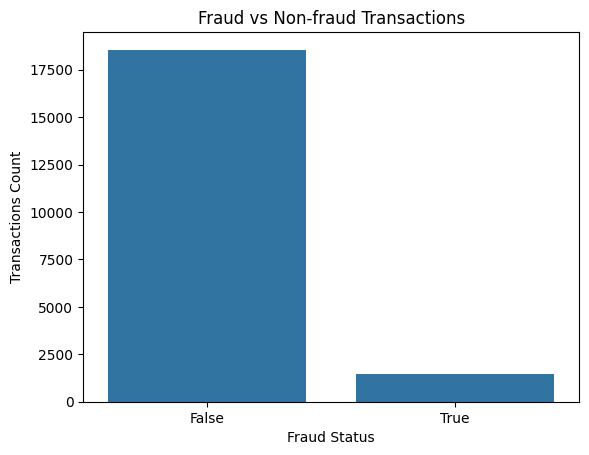

In [130]:
# Visualizing fraud vs non-fraud transaction distribution

sns.countplot(x = 'is_fraud', data = df)
plt.title('Fraud vs Non-fraud Transactions')
plt.xlabel('Fraud Status')
plt.ylabel('Transactions Count')
plt.show()

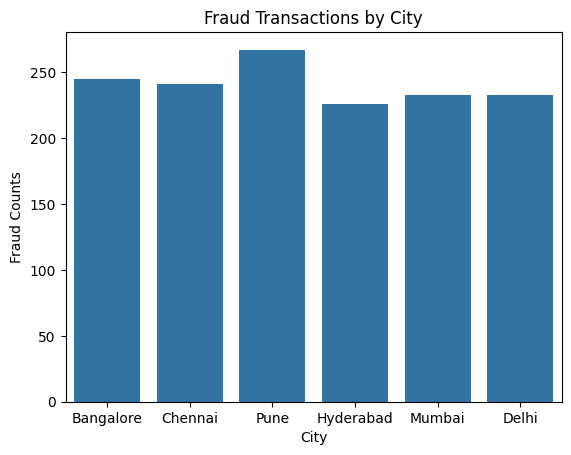

In [131]:
# Visualizing fraud transactions by city to identify fraud hotspots

fraud_data = df[df['is_fraud'] == True]

sns.countplot(x = 'location', data = fraud_data)
plt.title('Fraud Transactions by City')
plt.xlabel('City')
plt.ylabel('Fraud Counts')
plt.show()

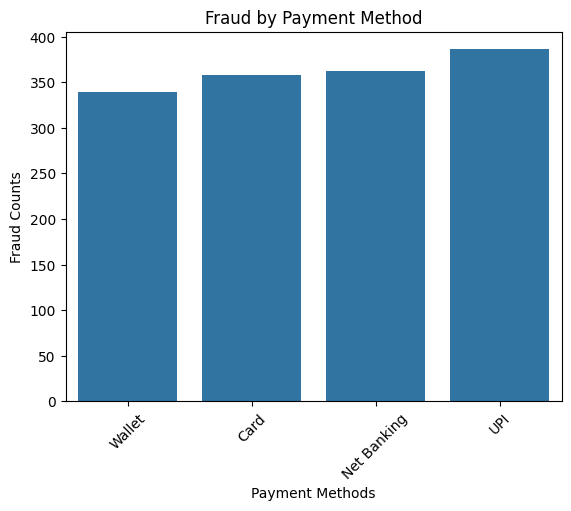

In [132]:
# Visualizing fraud transactions by payment method to identify vulnerable channels

sns.countplot(x = 'payment_method', data = fraud_data)
plt.title('Fraud by Payment Method')
plt.xlabel('Payment Methods')
plt.ylabel('Fraud Counts')
plt.xticks(rotation = 45)
plt.show()

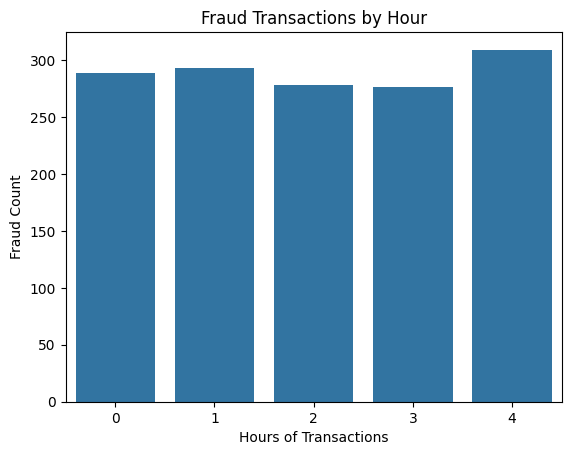

In [133]:
# Creating transaction_hour feature from transaction_time for time-based fraud analysis
df['transaction_hour'] = df['transaction_time'].dt.hour

fraud_data = df[df['is_fraud'] == True]

# Visualizing fraud distribution across transaction hours
sns.countplot(x = 'transaction_hour', data = fraud_data)
plt.title('Fraud Transactions by Hour')
plt.xlabel('Hours of Transactions')
plt.ylabel('Fraud Count')
plt.show()


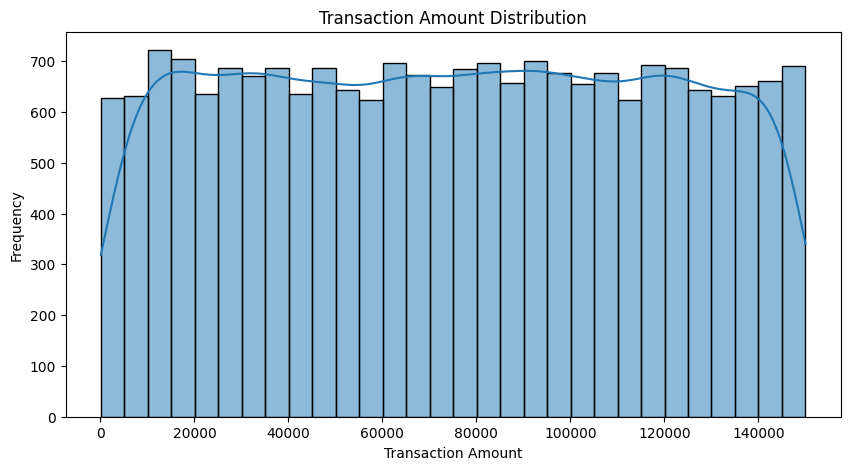

In [134]:
# Visualizing distribution of transaction amounts

plt.figure(figsize = (10, 5))
sns.histplot(df['amount'], bins = 30, kde = True)
plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

In [135]:
# Creating risk_level feature based on fraud conditions

def assign_risk(row):
    if row['amount'] > 50000 and row['failed_attempts'] >= 3 and 0 <= row['transaction_hour'] <= 4:
        return 'High Risk'
    elif row['amount'] > 30000 and row['failed_attempts'] >= 2:
        return 'Medium Risk'
    else:
        return 'Low Risk'
    
df['risk_level'] = df.apply(assign_risk, axis = 1)

In [136]:
# Checking distribution of transactions across risk levels

df['risk_level'].value_counts()

risk_level
Low Risk       9309
Medium Risk    9246
High Risk      1445
Name: count, dtype: int64

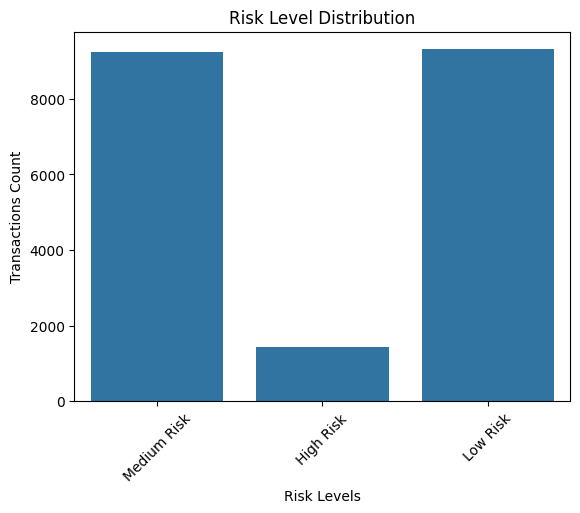

In [137]:
# Visualizing transaction distribution by risk level

sns.countplot(x = 'risk_level', data = df)
plt.title('Risk Level Distribution')
plt.xlabel('Risk Levels')
plt.ylabel('Transactions Count')
plt.xticks(rotation = 45)
plt.show()

In [138]:
# Creating amount_category feature based on transaction amount

def amount_category(amount):
    if amount < 20000:
        return 'Low Amount'
    elif amount < 70000:
        return 'Medium Amount'
    else:
        return 'High Amount'
    
df['amount_category'] = df['amount'].apply(amount_category)
        

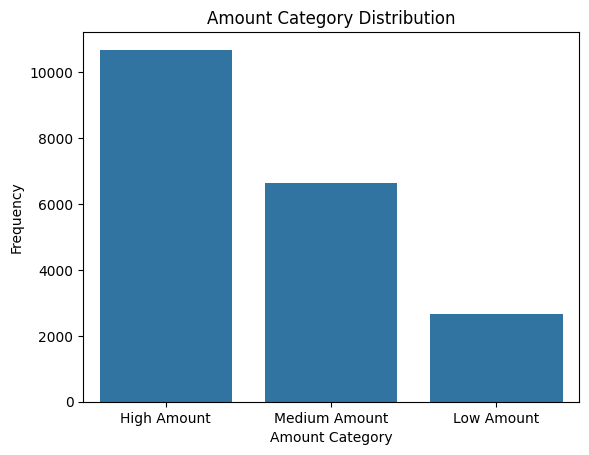

In [139]:
# Visualizing amount category distribution

sns.countplot(x = 'amount_category', data = df)
plt.title("Amount Category Distribution")
plt.xlabel('Amount Category')
plt.ylabel('Frequency')
plt.show()

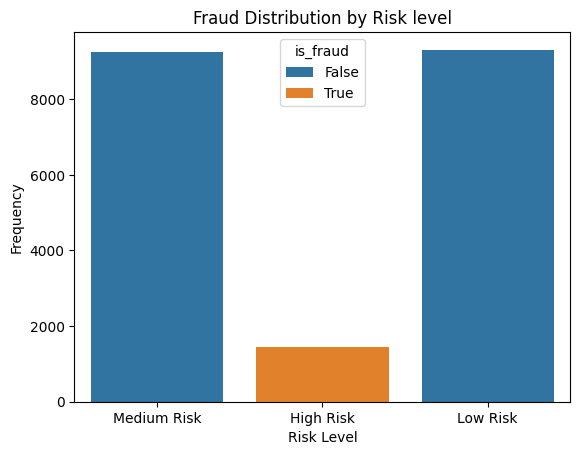

In [140]:
# Visualizing fraud count across risk levels
sns.countplot(x = 'risk_level', hue = 'is_fraud', data = df)
plt.title('Fraud Distribution by Risk level')
plt.xlabel('Risk Level')
plt.ylabel('Frequency')
plt.show()

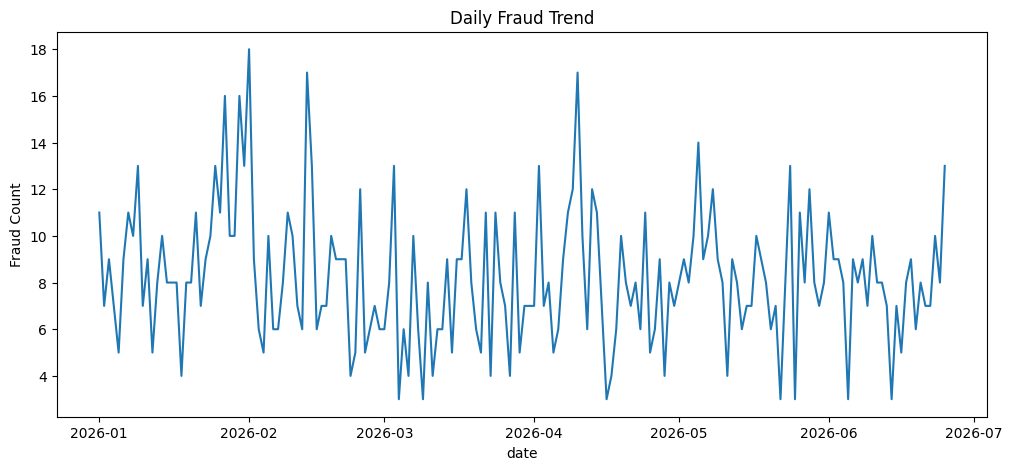

In [141]:
# Extracting transaction date for trend analysis
df['transaction_date'] = df['transaction_time'].dt.date

# Visualizing daily fraud trend
daily_fraud = df[df['is_fraud'] == True].groupby('transaction_date').size()

plt.figure(figsize = (12, 5))
daily_fraud.plot(kind = 'line')
plt.title('Daily Fraud Trend')
plt.xlabel('date')
plt.ylabel('Fraud Count')
plt.show()

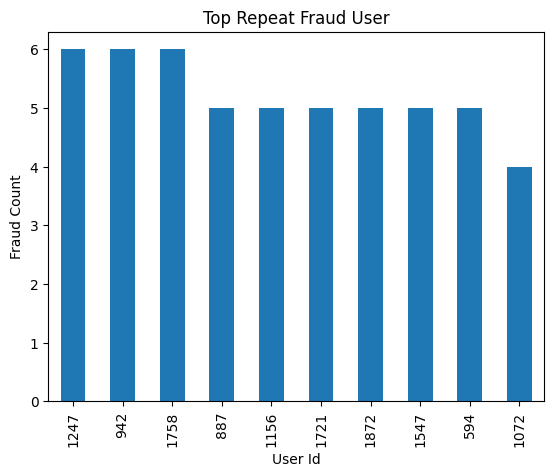

In [142]:
# Identifying repeat fraud users
repeat_fraud_user = df[df['is_fraud'] == True]['user_id'].value_counts().head(10)

# Visualizing top repeat fraud users
repeat_fraud_user.plot(kind = 'bar')
plt.title('Top Repeat Fraud User')
plt.xlabel('User Id')
plt.ylabel('Fraud Count')
plt.show()

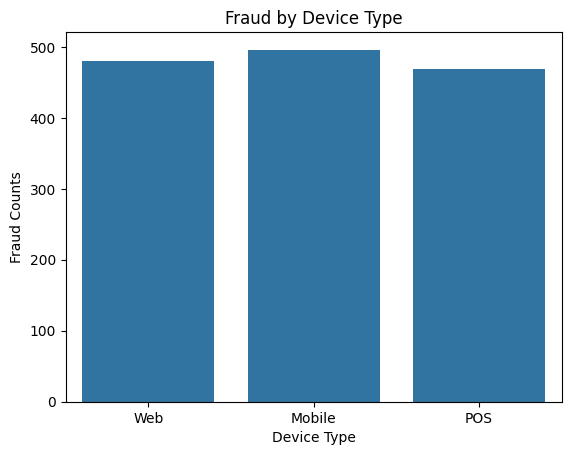

In [143]:
# Visualizing fraud by device type
sns.countplot(x = 'device_type', data = fraud_data)
plt.title('Fraud by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Fraud Counts')
plt.show()

In [144]:
# Comparing average transaction amount for fraud vs non-fraud
df.groupby('is_fraud')['amount'].mean()

is_fraud
False    73099.862684
True     99806.181654
Name: amount, dtype: float64

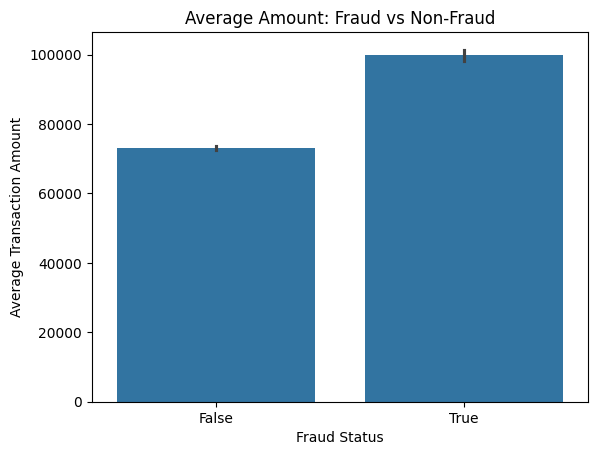

In [145]:
# Visualizing average amount by fraud status
sns.barplot(x = 'is_fraud', y = 'amount', data = df)
plt.title("Average Amount: Fraud vs Non-Fraud")
plt.xlabel("Fraud Status")
plt.ylabel("Average Transaction Amount")
plt.show()

In [146]:
# Exporting final engineered dataset for Power BI dashboard
df.to_csv('fraud_dashboard_dataset.csv', index = False)